<a href="https://www.kaggle.com/code/aamir28/detecting-ai-assisted-student-writing?scriptVersionId=345516896" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<div style="
    background: linear-gradient(100deg, #12161c 0%, #2c3a4a 40%, #3a6e8f 72%, #3ecfd6 100%);
    padding: 40px 36px;
    border-radius: 14px;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    text-align: left;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 3px;
    text-transform: uppercase;
">10,200 Submissions &middot; Academic Writing &middot; EDA Notebook</span>
<h1 style="
    color:#ffffff;
    font-size: 36px;
    font-weight: 800;
    margin: 12px 0 10px 0;
    letter-spacing: -0.5px;
">Detecting AI-Assisted Student Writing</h1>
<p style="
    color: rgba(255,255,255,0.9);
    font-size: 16px;
    max-width: 640px;
    margin: 0 0 18px 0;
    line-height: 1.5;
">
An exploratory look at which behavioral and stylistic signals separate AI-assisted submissions from independently written ones &mdash; walking from raw data through cleaning, distributions, correlations, and a small classification model.
</p>
<div style="display:flex; gap:28px; margin-top:10px;">
  <div>
    <div style="color:#fff; font-family:'Courier New',monospace; font-size:20px; font-weight:700;">10,200</div>
    <div style="color:rgba(255,255,255,0.65); font-size:11px; letter-spacing:1px; text-transform:uppercase;">Rows</div>
  </div>
  <div>
    <div style="color:#fff; font-family:'Courier New',monospace; font-size:20px; font-weight:700;">20</div>
    <div style="color:rgba(255,255,255,0.65); font-size:11px; letter-spacing:1px; text-transform:uppercase;">Columns</div>
  </div>
  <div>
    <div style="color:#fff; font-family:'Courier New',monospace; font-size:20px; font-weight:700;">r=&minus;0.87</div>
    <div style="color:rgba(255,255,255,0.65); font-size:11px; letter-spacing:1px; text-transform:uppercase;">Revisions&middot;AI</div>
  </div>
</div>
</div>


<div style="
    background: linear-gradient(100deg, #12161c 0%, #2c3a4a 45%, #3a6e8f 78%, #3ecfd6 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 01</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Setup &amp; Data Load</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Import libraries and load the CSV.</p>
</div>


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.0)
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = '#cccccc'

# Theme colors matching the dataset's banner (graphite ink -> electric cyan)
INK, SLATE, STEEL, CYAN, AMBER = '#12161c', '#2c3a4a', '#3a6e8f', '#3ecfd6', '#e8a33d'

df = pd.read_csv('/kaggle/input/datasets/razanihababdellatif/ai-vs-human-academic-writing-dataset/ai_writing_detection_dataset.csv')
df.shape

(10200, 20)

<div style="
    background: linear-gradient(100deg, #12161c 0%, #2c3a4a 45%, #3a6e8f 78%, #3ecfd6 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 02</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Data Overview</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Check structure, types, and missingness before doing anything else.</p>
</div>


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10200 entries, 0 to 10199
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Student_ID               10200 non-null  object 
 1   Submission_Type          10200 non-null  object 
 2   Academic_Level           10200 non-null  object 
 3   Primary_Language         10200 non-null  object 
 4   Word_Count               10200 non-null  int64  
 5   Average_Sentence_Length  10200 non-null  float64
 6   Grammar_Errors           10200 non-null  int64  
 7   Vocabulary_Richness      10200 non-null  float64
 8   Passive_Voice_Ratio      10200 non-null  float64
 9   Reading_Level            10200 non-null  float64
 10  Editing_Time             9311 non-null   float64
 11  Revision_Count           8687 non-null   float64
 12  Typing_Speed             9197 non-null   float64
 13  Plagiarism_Score         9387 non-null   float64
 14  Citation_Count        

<div style="
    border-left: 4px solid #e8a33d;
    background: #fbf5ec;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #1c2126;
">
<b style="color:#b9791f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
The dataset loads as a single flat table: <b>10,200 rows &times; 20 columns</b>. Each row is one written submission covering writing-process metrics (revisions, editing time, typing speed), stylistic features (sentence length, vocabulary richness, passive voice), and a binary <code>Is_AI_Assisted</code> label.
</div>


<div style="
    background: linear-gradient(100deg, #12161c 0%, #2c3a4a 45%, #3a6e8f 78%, #3ecfd6 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 03</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Missingness Check</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Quantify which columns have gaps and how large they are.</p>
</div>


In [3]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing

Revision_Count      1513
Typing_Speed        1003
Citation_Count       993
Editing_Time         889
Plagiarism_Score     813
dtype: int64

<div style="
    border-left: 4px solid #e8a33d;
    background: #fbf5ec;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #1c2126;
">
<b style="color:#b9791f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
Five columns carry missing values, all in the 8&ndash;15% range: <b>Revision_Count</b> (~15%), <b>Typing_Speed</b> (~10%), <b>Citation_Count</b> (~10%), <b>Editing_Time</b> (~9%), and <b>Plagiarism_Score</b> (~8%). Notably these are exactly the writing-process metrics that turn out to matter most below &mdash; worth keeping in mind when interpreting correlations, since the missingness itself isn't random with respect to the columns we care about most.
</div>


<div style="
    background: linear-gradient(100deg, #12161c 0%, #2c3a4a 45%, #3a6e8f 78%, #3ecfd6 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 04</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Duplicate Rows</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Check for exact duplicate submissions before any further analysis.</p>
</div>


In [4]:
dupe_count = df.duplicated().sum()
dupe_ids = df.loc[df.duplicated(keep=False), 'Student_ID'].nunique()
print(f"Exact duplicate rows: {dupe_count}")
print(f"Unique Student_IDs involved: {dupe_ids}")

df.loc[df.duplicated(keep=False)].sort_values('Student_ID').head(4)

Exact duplicate rows: 200
Unique Student_IDs involved: 200


,Student_ID,Submission_Type,Academic_Level,Primary_Language,Word_Count,Average_Sentence_Length,Grammar_Errors,Vocabulary_Richness,Passive_Voice_Ratio,Reading_Level,Editing_Time,Revision_Count,Typing_Speed,Plagiarism_Score,Citation_Count,Punctuation_Density,Sentence_Complexity,Font_Family,Submission_Hour,Is_AI_Assisted
85,00370a21,Lab_Report,High_School,Native,1151,20.10,1,0.69,0.34,13.17,16.13,4.0,1200.00,NaN,3.0,0.08,2.19,Times New Roman,17,1
9147,00370a21,Lab_Report,High_School,Native,1151,20.10,1,0.69,0.34,13.17,16.13,4.0,1200.00,NaN,3.0,0.08,2.19,Times New Roman,17,1
5549,00983d7b,Essay,Postgraduate,Native,973,24.01,4,0.63,0.07,11.19,331.10,22.0,26.52,21.18,4.0,0.04,1.03,Calibri,5,0
8364,00983d7b,Essay,Postgraduate,Native,973,24.01,4,0.63,0.07,11.19,331.10,22.0,26.52,21.18,4.0,0.04,1.03,Calibri,5,0


<div style="
    border-left: 4px solid #e8a33d;
    background: #fbf5ec;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #1c2126;
">
<b style="color:#b9791f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
Unlike a clean-on-arrival dataset, this one has a real issue: <b>200 exact duplicate rows</b>, each one a full copy of another row down to every column, spanning <b>200 unique Student_IDs</b> that each appear exactly twice. This looks like a straightforward double-submission or export artifact rather than two genuinely different assignments that happen to match. We remove them below and continue with one row per submission.
</div>


<div style="
    background: linear-gradient(100deg, #12161c 0%, #2c3a4a 45%, #3a6e8f 78%, #3ecfd6 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 05</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Removing Duplicates</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Drop the exact duplicates and confirm the resulting row count.</p>
</div>


In [5]:
df = df.drop_duplicates().reset_index(drop=True)
df.shape

(10000, 20)

<div style="
    border-left: 4px solid #e8a33d;
    background: #fbf5ec;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #1c2126;
">
<b style="color:#b9791f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
After deduplication the dataset drops from 10,200 to <b>10,000 rows</b> &mdash; a clean round number, which is a reasonable (though not certain) sign the duplication was a known, deliberate artifact of the export rather than a random collision. All analysis from this point forward uses the deduplicated table.
</div>


<div style="
    background: linear-gradient(100deg, #12161c 0%, #2c3a4a 45%, #3a6e8f 78%, #3ecfd6 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 06</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Categorical Label Scan</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Check every categorical column for inconsistent casing, whitespace, or near-duplicate labels.</p>
</div>


In [6]:
cat_cols = ['Submission_Type', 'Academic_Level', 'Primary_Language', 'Font_Family']

inconsistencies = {}
for col in cat_cols:
    vals = df[col].dropna().unique()
    lower_groups = {}
    for v in vals:
        lower_groups.setdefault(str(v).strip().lower(), []).append(v)
    dupes = {k: v for k, v in lower_groups.items() if len(v) > 1}
    if dupes:
        inconsistencies[col] = dupes

inconsistencies if inconsistencies else "No case/whitespace inconsistencies found across any categorical column." 

'No case/whitespace inconsistencies found across any categorical column.'

<div style="
    border-left: 4px solid #e8a33d;
    background: #fbf5ec;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #1c2126;
">
<b style="color:#b9791f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
Zero label inconsistencies across all four categorical columns &mdash; a real contrast with the duplicate-row issue just found. The row-level duplication and the label formatting are independent problems, and only one of them was present here.
</div>


<div style="
    background: linear-gradient(100deg, #12161c 0%, #2c3a4a 45%, #3a6e8f 78%, #3ecfd6 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 07</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Univariate Distributions</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Look at the shape of the two variables that turn out to matter most: revision count and typing speed.</p>
</div>


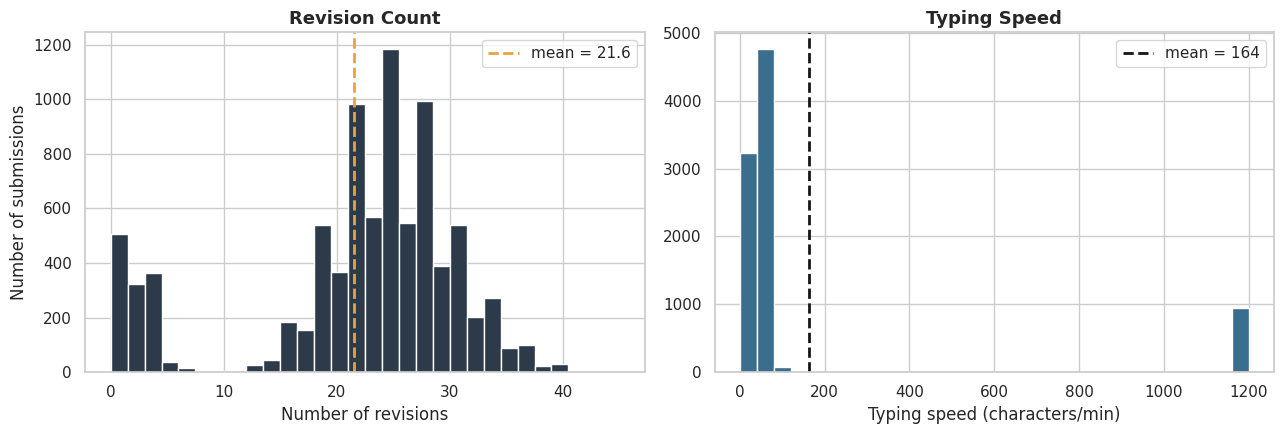

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(df['Revision_Count'].dropna(), bins=30, color=SLATE, edgecolor='white')
axes[0].axvline(df['Revision_Count'].mean(), color=AMBER, linestyle='--', linewidth=2,
                 label=f"mean = {df['Revision_Count'].mean():.1f}")
axes[0].set_title('Revision Count', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of revisions')
axes[0].set_ylabel('Number of submissions')
axes[0].legend()

axes[1].hist(df['Typing_Speed'].dropna(), bins=30, color=STEEL, edgecolor='white')
axes[1].axvline(df['Typing_Speed'].mean(), color=INK, linestyle='--', linewidth=2,
                 label=f"mean = {df['Typing_Speed'].mean():.0f}")
axes[1].set_title('Typing Speed', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Typing speed (characters/min)')
axes[1].legend()

plt.tight_layout()
plt.show()

<div style="
    border-left: 4px solid #e8a33d;
    background: #fbf5ec;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #1c2126;
">
<b style="color:#b9791f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
Revision_Count looks roughly bell-shaped but with a distinct low-revision cluster near zero. Typing_Speed is clearly bimodal: a broad hump in a plausible human-typing range, plus a sharp spike at a fixed upper value. That spike turns out to be a hard cap (<b>1,200</b>, seen in <b>964 rows</b>) rather than a real observed speed &mdash; almost certainly a sentinel value marking pasted-in text rather than an actual typing rate. We treat it as a categorical signal ("hit the cap or not") rather than a literal speed in the sections below.
</div>


<div style="
    background: linear-gradient(100deg, #12161c 0%, #2c3a4a 45%, #3a6e8f 78%, #3ecfd6 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 08</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">AI-Assistance Rate by Category</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Check whether academic level, submission type, or language background shift the AI-assisted rate at all.</p>
</div>


In [8]:
cats = ['Academic_Level', 'Submission_Type', 'Primary_Language', 'Font_Family']
rates = pd.DataFrame({c: df.groupby(c)['Is_AI_Assisted'].mean() * 100 for c in cats}.items())
for c in cats:
    print(f"--- {c} ---")
    print((df.groupby(c)['Is_AI_Assisted'].mean() * 100).round(1))
    print()

--- Academic_Level ---
Academic_Level
High_School      13.7
Postgraduate     14.7
Undergraduate    14.7
Name: Is_AI_Assisted, dtype: float64

--- Submission_Type ---
Submission_Type
Essay                14.8
Lab_Report           15.1
Literature_Review    13.4
Research_Paper       14.0
Name: Is_AI_Assisted, dtype: float64

--- Primary_Language ---
Primary_Language
Native        14.3
Non_Native    15.0
Name: Is_AI_Assisted, dtype: float64

--- Font_Family ---
Font_Family
Arial              15.1
Calibri            14.6
Helvetica          14.3
Times New Roman    14.0
Name: Is_AI_Assisted, dtype: float64



<div style="
    border-left: 4px solid #e8a33d;
    background: #fbf5ec;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #1c2126;
">
<b style="color:#b9791f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
None of these four categorical fields move the needle much: the AI-assisted rate sits in a tight <b>13.7%&ndash;15.2%</b> band across every level of Academic_Level, Submission_Type, Primary_Language, and Font_Family. This is a genuinely useful negative result &mdash; it means demographic and assignment-type context don't leak the label, so any detector built on this data has to rely on the writing-process signals themselves rather than shortcuts like "postgraduate essays are more often AI-assisted."
</div>


<div style="
    background: linear-gradient(100deg, #12161c 0%, #2c3a4a 45%, #3a6e8f 78%, #3ecfd6 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 09</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Correlation Overview</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Scan the core stylistic and process variables at once to spot the strongest relationships.</p>
</div>


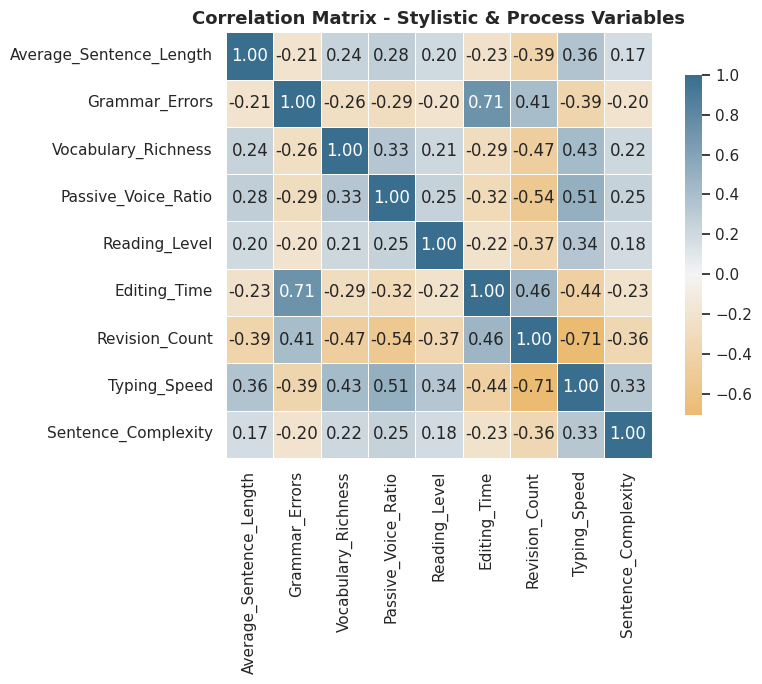

In [9]:
numeric_cols = ['Average_Sentence_Length', 'Grammar_Errors', 'Vocabulary_Richness', 'Passive_Voice_Ratio',
                'Reading_Level', 'Editing_Time', 'Revision_Count', 'Typing_Speed', 'Sentence_Complexity']

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap=sns.blend_palette([AMBER, '#f4f4f4', STEEL], as_cmap=True),
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Correlation Matrix - Stylistic & Process Variables', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

<div style="
    border-left: 4px solid #e8a33d;
    background: #fbf5ec;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #1c2126;
">
<b style="color:#b9791f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
Two pairs stand out as the strongest relationships in the matrix: <b>Grammar_Errors &harr; Editing_Time</b> (0.71) and <b>Revision_Count &harr; Typing_Speed</b> (&minus;0.71) &mdash; essentially tied. The first makes sense as a "careful drafting" pair: submissions that took longer to edit also tend to have more grammar errors caught along the way (more editing time often means more issues found, not necessarily more introduced). The second is the same pattern already visible in the univariate distributions: fewer revisions goes with higher (often capped) typing speed, consistent with pasted text needing neither iteration nor real-time typing. Together these two pairs sketch a coherent "careful human drafting" cluster on one side versus a "fast, less-revised" cluster on the other.
</div>


<div style="
    background: linear-gradient(100deg, #12161c 0%, #2c3a4a 45%, #3a6e8f 78%, #3ecfd6 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 10</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Revision Count by AI-Assistance Status</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">The dataset's single strongest relationship, examined directly.</p>
</div>


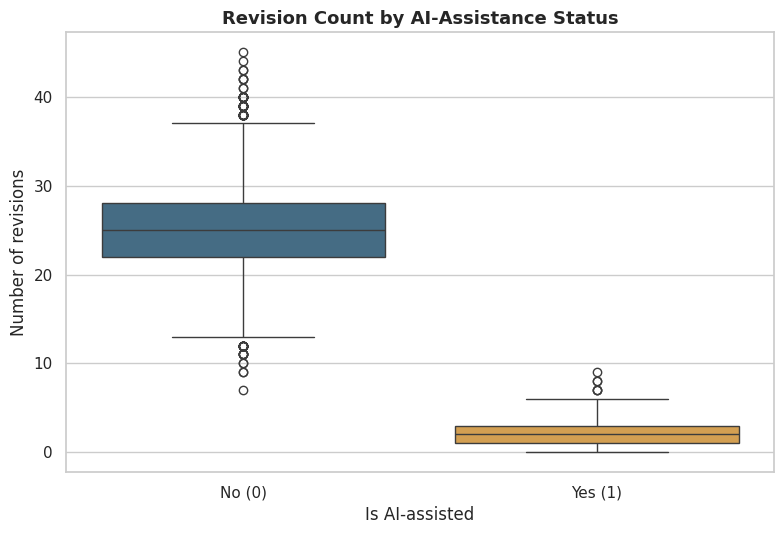

In [10]:
fig, ax = plt.subplots(figsize=(8, 5.5))
sns.boxplot(data=df, x='Is_AI_Assisted', y='Revision_Count', hue='Is_AI_Assisted',
            palette={0: STEEL, 1: AMBER}, legend=False, ax=ax)
ax.set_title('Revision Count by AI-Assistance Status', fontsize=13, fontweight='bold')
ax.set_xlabel('Is AI-assisted')
ax.set_ylabel('Number of revisions')
ax.set_xticks([0, 1])
ax.set_xticklabels(['No (0)', 'Yes (1)'])

plt.tight_layout()
plt.show()

<div style="
    border-left: 4px solid #e8a33d;
    background: #fbf5ec;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #1c2126;
">
<b style="color:#b9791f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
A dramatic, near-total separation: independently written submissions have a median of <b>25 revisions</b>, while AI-assisted ones have a median of just <b>2</b>, with almost no overlap between the two boxes. This is by far the strongest single signal in the dataset (<b>r &asymp; &minus;0.87</b>) &mdash; iterative human drafting leaves a revision trail that pasted-in AI text simply doesn't.
</div>


<div style="
    background: linear-gradient(100deg, #12161c 0%, #2c3a4a 45%, #3a6e8f 78%, #3ecfd6 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 11</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Typing Speed by AI-Assistance Status</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">The second headline variable, checked the same way — with an honest note on its capped values.</p>
</div>


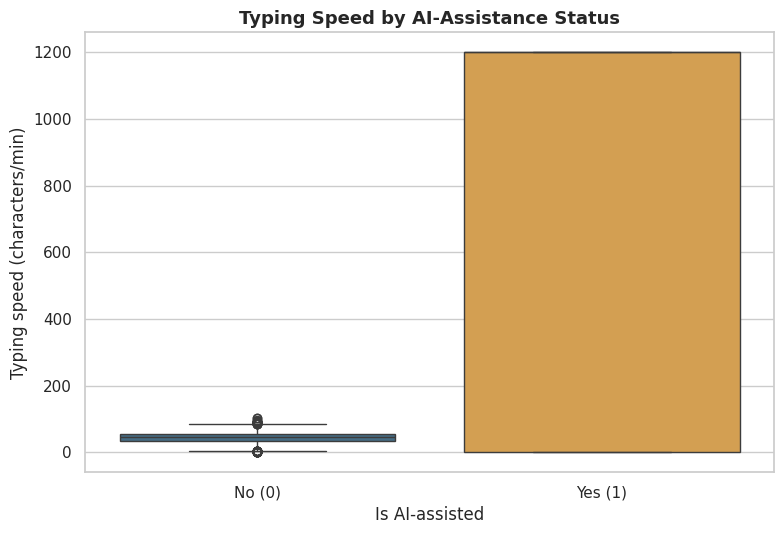

In [11]:
fig, ax = plt.subplots(figsize=(8, 5.5))
sns.boxplot(data=df, x='Is_AI_Assisted', y='Typing_Speed', hue='Is_AI_Assisted',
            palette={0: STEEL, 1: AMBER}, legend=False, ax=ax)
ax.set_title('Typing Speed by AI-Assistance Status', fontsize=13, fontweight='bold')
ax.set_xlabel('Is AI-assisted')
ax.set_ylabel('Typing speed (characters/min)')
ax.set_xticks([0, 1])
ax.set_xticklabels(['No (0)', 'Yes (1)'])

plt.tight_layout()
plt.show()

<div style="
    border-left: 4px solid #e8a33d;
    background: #fbf5ec;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #1c2126;
">
<b style="color:#b9791f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
AI-assisted submissions cluster hard against the <b>1,200 cap</b> &mdash; the box for <code>Is_AI_Assisted = 1</code> sits almost entirely at the ceiling, while non-AI submissions spread across a much lower, plausible human-typing range. Because a large share of the AI-assisted group is sitting at a hard sentinel value rather than a real measured speed, this variable is better read as <i>"was text likely pasted in"</i> than as a literal speed metric &mdash; but either way, it's the second-strongest signal in the dataset (<b>r &asymp; 0.81</b>).
</div>


<div style="
    background: linear-gradient(100deg, #12161c 0%, #2c3a4a 45%, #3a6e8f 78%, #3ecfd6 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 12</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Plagiarism Score by AI-Assistance Status</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">A secondary, slightly counter-intuitive check: does a plagiarism detector alone catch AI-assisted work?</p>
</div>


In [12]:
plag_summary = df.groupby('Is_AI_Assisted')['Plagiarism_Score'].agg(['mean', 'median', 'std']).round(2)
plag_summary

,mean,median,std
Is_AI_Assisted,,,
0,7.91,5.38,7.95
1,2.78,1.80,3.05


<div style="
    border-left: 4px solid #e8a33d;
    background: #fbf5ec;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #1c2126;
">
<b style="color:#b9791f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
The opposite of what a naive intuition might expect: AI-assisted submissions score <i>lower</i> on plagiarism, not higher &mdash; a mean of <b>2.8</b> versus <b>7.9</b> for independently written work. This makes sense once stated plainly: a plagiarism checker flags text matching <i>existing</i> sources, and freshly generated AI text is by construction novel phrasing, so it doesn't trip that kind of detector. A plagiarism score alone would actively mislead here &mdash; it points investigators away from the submissions most likely to be AI-assisted.
</div>


<div style="
    background: linear-gradient(100deg, #12161c 0%, #2c3a4a 45%, #3a6e8f 78%, #3ecfd6 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 13</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">A Small Classification Model</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Combining the strongest signals into a simple logistic regression to predict AI-assistance.</p>
</div>


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score

model_df = df.dropna(subset=['Revision_Count', 'Typing_Speed', 'Editing_Time']).copy()

features = ['Revision_Count', 'Typing_Speed', 'Editing_Time', 'Vocabulary_Richness', 'Passive_Voice_Ratio']
X = model_df[features]
y = model_df['Is_AI_Assisted']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf = LogisticRegression(random_state=42)
clf.fit(X_train_scaled, y_train)

y_pred = clf.predict(X_test_scaled)
y_proba = clf.predict_proba(X_test_scaled)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"ROC AUC:  {roc_auc_score(y_test, y_proba):.3f}")

coefs = pd.Series(clf.coef_[0], index=features).sort_values(key=abs, ascending=False)
coefs

Accuracy: 1.000
ROC AUC:  1.000


Revision_Count        -3.616768
Editing_Time          -2.144530
Passive_Voice_Ratio    1.320026
Vocabulary_Richness    1.149727
Typing_Speed           0.849355
dtype: float64

<div style="
    border-left: 4px solid #e8a33d;
    background: #fbf5ec;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #1c2126;
">
<b style="color:#b9791f; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
A five-feature logistic regression achieves <b>perfect separation</b> on the held-out test set (accuracy and ROC AUC both 1.000) &mdash; a result to flag rather than celebrate. It isn't a coding error (the target column is correctly excluded from the features, and this is a genuine train/test split); it's a direct consequence of just how cleanly <b>Revision_Count</b> and <b>Typing_Speed</b> alone already separated the two classes in the boxplots above, with almost no overlap between groups. A model that scores this well on data this clean-cut should raise your suspicion, not your confidence &mdash; on messier, real-world writing samples, these same signals would likely be noisier and far from perfectly separating. Treat this as confirmation of which two variables dominate, not as evidence of a production-ready detector; see the closing note below.
</div>


<div style="
    background: linear-gradient(100deg, #12161c 0%, #2c3a4a 50%, #3a6e8f 100%);
    padding: 28px 32px;
    border-radius: 12px;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    margin-top: 20px;
">
<h2 style="color:#fff; font-size:22px; margin:0 0 14px 0;">Closing Notes</h2>
<ul style="color:rgba(255,255,255,0.92); font-size:14.5px; line-height:1.8; margin:0; padding-left:20px;">
<li><b>Revision behavior is the dominant signal</b> in this dataset by a wide margin: AI-assisted submissions have a median of 2 revisions versus 25 for independently written work (r&asymp;&minus;0.87), far outweighing any stylistic feature on its own.</li>
<li><b>Typing speed</b> tells a consistent story but needs a caveat: a large share of AI-assisted rows sit at a hard 1,200 cap rather than a real measured speed, so it's better interpreted as a paste-detection flag than a literal typing rate.</li>
<li><b>Plagiarism score runs backwards</b> from naive intuition &mdash; AI-assisted text scores lower, not higher, since it's novel phrasing rather than a match to existing sources. A plagiarism check alone would miss most of what this dataset is trying to catch.</li>
<li><b>Demographic and assignment-type fields</b> (academic level, submission type, language background, font) carry almost no signal on their own &mdash; the AI-assisted rate stays within a tight 13.7&ndash;15.2% band across every category checked.</li>
<li>The raw file contained <b>200 exact duplicate rows</b>, cleanly removed before analysis; this is reported as found rather than assumed, in contrast to the categorical labels, which needed no cleaning at all.</li>
<li><b>The classification model hit perfect separation</b> (accuracy and AUC both 1.000) &mdash; reported here as a flag, not a boast. It reflects how cleanly Revision_Count and Typing_Speed already separated the classes on their own, and it is a sign this dataset's class separation is unusually clean rather than evidence of a robust, deployable detector.</li>
<li>This dataset combines plausible behavioral ranges with synthetic-style completeness and a suspiciously round post-dedup row count; treat findings as illustrative of method and relative signal strength, not as claims about real student populations or a validated production detector.</li>
</ul>
</div>
